In [13]:
import os
import math
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from torch.utils.data import Dataset, DataLoader

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from tqdm.notebook import tqdm
import numpy as np

from torch.utils.data import DataLoader
from torchvision.utils import save_image
from torchvision.io import read_image
from torchvision.transforms import Resize, v2
from torchvision.transforms import Compose, ToTensor, Lambda, Pad
from PIL import Image
from sklearn.metrics import confusion_matrix
import seaborn as sns
nn = torch.nn
F = nn.functional


print(torch.cuda.is_available())

True


In [14]:
class Simple_CNN(nn.Module):
    def __init__(self):
        super(Simple_CNN, self).__init__()
        
        base_model = models.resnet50(pretrained=True)
        for name, param in base_model.named_children():
            if name not in ['avgpool', 'fc']:
                for layer in param.parameters():
                    layer.requires_grad = False
                    
        self.channels = [3, 32, 64, 128, 256, 512, 51200, 2]
        self.resnet = base_model
        self.down_new = nn.Sequential(
            nn.Linear(1000, 2),
            nn.Softmax(dim=1)
        )
        self.down = nn.Sequential(
            nn.Conv2d(self.channels[0], self.channels[1], kernel_size=3),
            nn.BatchNorm2d(self.channels[1]),
            nn.ReLU(),
            nn.Conv2d(self.channels[1], self.channels[2], kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(self.channels[2], self.channels[3], kernel_size=3),
            nn.BatchNorm2d(self.channels[3]),
            nn.ReLU(),
            nn.Conv2d(self.channels[3], self.channels[4], kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(self.channels[4], self.channels[5], kernel_size=3),
            nn.BatchNorm2d(self.channels[5]),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(self.channels[6], self.channels[7]),
            nn.Softmax(dim=1)
        )


    def forward(self, x):
        x = self.resnet(x)
        x = self.down_new(x)
        return x



In [15]:
class CustomResNet(nn.Module):
    def __init__(self):
        base_model = models.resnet50(pretrained = True)
        super(CustomResNet, self).__init__()
        self.base_model = base_model
        self.dropout = nn.Dropout(0.3)
        self.flatten = nn.Flatten()
        self.batchnorm1 = nn.BatchNorm1d(1000)
        self.dense1 = nn.Linear(1000, 32)
        self.dropout = nn.Dropout(0.3)
        self.batchnorm2 = nn.BatchNorm1d(32)
        self.activation = nn.ReLU()
        self.dense2 = nn.Linear(32, 8)
        self.sm = torch.nn.Softmax()

    def forward(self, x):
        x = self.base_model(x)
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.batchnorm1(x)
        x = self.dense1(x)
        x = self.batchnorm2(x)
        x = self.activation(x)
        x = self.dense2(x)
        x = self.sm(x)
        return x

In [16]:
def detect_faces(rectangles, density_threshold=8):
    """
    Detect faces based on the density of overlapping patches.
    """
    density_map = np.zeros((512, 512))
    for rectangle in rectangles:
        x1, y1, x2, y2 = rectangle
        density_map[y1:y2, x1:x2] += 1

    thresholded_map_np = density_map > density_threshold
    thresholded_map_tensor = torch.from_numpy(thresholded_map_np)

    contours, _ = cv2.findContours(thresholded_map_tensor.numpy().astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    face_rectangles = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        face_rectangles.append((x, y, w, h))

    return face_rectangles

In [17]:
def get_face_rectangles(patches, xs, ys, threshold):
    rectangles = []
    for j, patch in enumerate(patches):
        patch = patch.to('cuda')
        patch_size = 100 
        
        output = torch.argmax(facefinder(patch.unsqueeze(0).permute(0, 3, 1, 2).float()), dim=1)
        
        if output.item() == 1:
            x = xs[j]
            y = ys[j]
            rect = (x, y, x + patch_size, y + patch_size)
            rectangles.append(rect)

    face_rectangles = detect_faces(rectangles, threshold)
    return face_rectangles


In [18]:
def create_patches(img, size = (100, 100), step_size = 25):
    
    width = 512  # Get the width of the image (dimension at index 1)
    height = 512
    
    patches = []
    pos_patches = []
    neg_patches = []
    labels = []
    xs = []
    ys = []
    
    step = step_size
    x = 0
    y = 0
    
    threashold = 0.6
    pos = 0
    neg = 0
    #read bboxes and their
    x_bbox = [0] * num_faces[0]
    y_bbox = [0] * num_faces[0]
    w_bbox = [0] * num_faces[0]
    h_bbox = [0] * num_faces[0]

    while(y + size[1] < height):
        while(x + size[0] < width):
            patch = img[y:y + size[1], x:x + size[0], :] #create patch
            patches.append(patch) 
            xs.append(x)
            ys.append(y)
                
            x += step
        y += step
        x = 0
    return patches, xs, ys


In [19]:
def get_selfies(model, picture):
    patch_size = 100
    step_size = 10  
    threshold = 40
    
    model.to('cuda')
    
    model.eval() 
    
    
    img = picture
    
    img = img.to('cuda')
    
    # Create patches from the sample and label
    patches, xs, ys = create_patches(img, step_size = step_size)
    
    # Display the original image
    plt.imshow((img / 255.).cpu())
    
    plt.title('Original Image')
    plt.axis('off')

    faces = get_face_rectangles(patches, xs, ys, threshold)
    selfies = []
    transform = transforms.Compose([
    transforms.Resize((224, 224))])
    nfaces=0
    returnpics = []
    for face in faces:
        x, y, w, h = face
        patch = img[y:y + h, x:x + w, :].cpu()
        patch = patch.permute(2,0,1)
        patch = transform(patch)
        returnpics.append(patch.permute(1,2,0))
        selfies.append(patch/255)
        nfaces+=1
    try:
        selfies = torch.stack(selfies, dim=0)
    except:
        return None
    selfies = selfies.to(torch.float32)
    if nfaces==1:
        selfis = selfies.unsqueeze(dim = 0)
    return selfies, returnpics

In [20]:
def show_multiple_images(images, titles):
    num_images = len(images)
    num_cols = min(num_images, 2)  # Maximum 2 columns
    num_rows = (num_images + num_cols - 1) // num_cols  # Calculate number of rows
    
    plt.figure(figsize=(6 * num_cols, 4 * num_rows))  # Adjust figure size based on number of images
    
    for i, (image, title) in enumerate(zip(images, titles), 1):
        plt.subplot(num_rows, num_cols, i)
        plt.imshow(image)
        plt.title(title)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [21]:
Emotion_model = torch.load("model40epoch_with_batchnorm.pth")

Label:  2
Prediction:  2
Outputs:  tensor([[2.2503e-03, 8.3217e-03, 9.3938e-01, 7.9706e-04, 9.1296e-03, 1.4526e-02,
         2.0955e-02, 4.6419e-03]], device='cuda:0', grad_fn=<SoftmaxBackward0>)


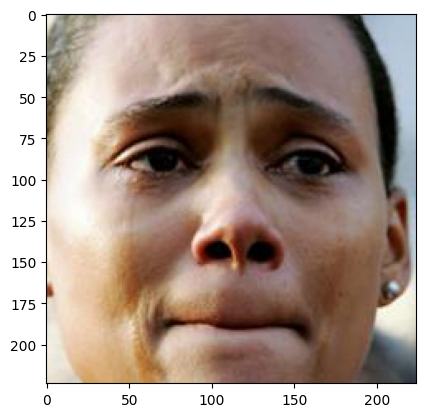

In [74]:
Pic_number = "414703"

sample = torch.tensor(np.copy(read_image('train_set/images/' + Pic_number + '.jpg').permute(1,2,0)/255)).to(torch.float32)
sample = sample.unsqueeze(dim = 0).permute(0,3,1,2).to('cuda')
data = np.load('train_set/annotations/' + Pic_number + '_exp.npy')
exp = Emotion_model(sample)

plt.imshow(read_image('train_set/images/' + Pic_number + '.jpg').permute(1,2,0))
print("Label: ", data)
print("Prediction: ", torch.argmax(exp).item())
print("Outputs: ", exp)

In [23]:
"""
KATEGORIER:
0 - Neutral
1 - Happy
2 - Sad
3 - Suprise
4 - Fear
5 - Disgust
6 - Anger
7 - Contempt
"""

'\nKATEGORIER:\n0 - Neutral\n1 - Happy\n2 - Sad\n3 - Suprise\n4 - Fear\n5 - Disgust\n6 - Anger\n7 - Contempt\n'

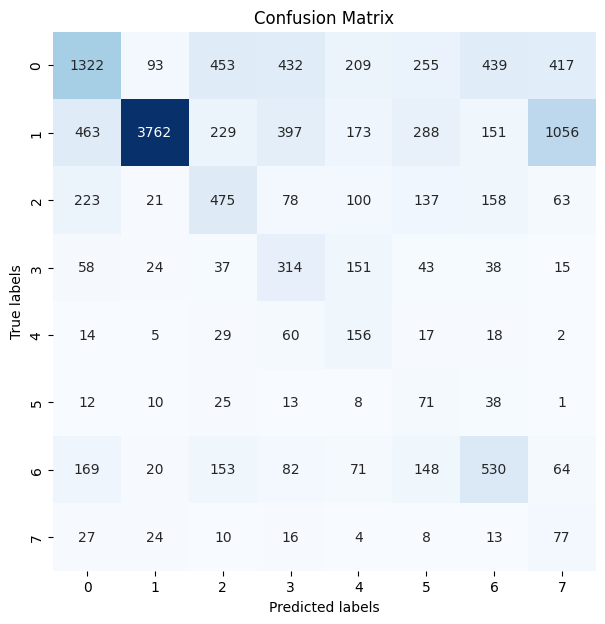

In [68]:
#CONFUSION MATRIX
start = 320000
nums = 20000
matrix = torch.zeros(8,8)
pred = []
data = []
for i in range(nums):
    Pic_number = start + i
    try:            
        file_name = 'train_set/annotations/' + str(Pic_number) + '_exp.npy'
        exp = np.load(file_name)
    except:
        continue

    sample = torch.tensor(np.copy(read_image('train_set/images/' + str(Pic_number) + '.jpg').permute(1,2,0)/255)).to(torch.float32)
    sample = sample.unsqueeze(dim = 0).permute(0,3,1,2).to('cuda')
    data.append(int(np.load('train_set/annotations/' + str(Pic_number) + '_exp.npy')))
    exp = Emotion_model(sample)
    pred.append(int(torch.argmax(exp).item()))

cm = confusion_matrix(data,pred)

plt.figure(figsize=(7,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()


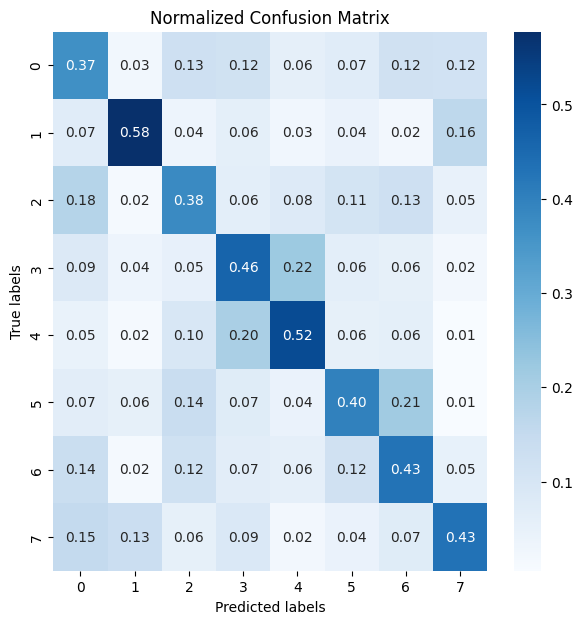

Number of tested samples:  13969


In [70]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the normalized confusion matrix
plt.figure(figsize=(7, 7))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', cbar=True)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Normalized Confusion Matrix')
plt.show()
print("Number of tested samples: ", len(data))

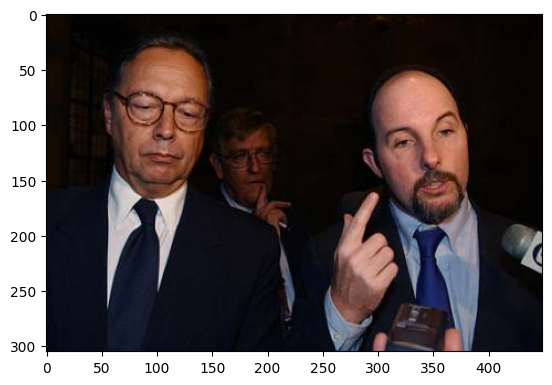

2548
2548
2548
Number of samples in the dataset:  2548


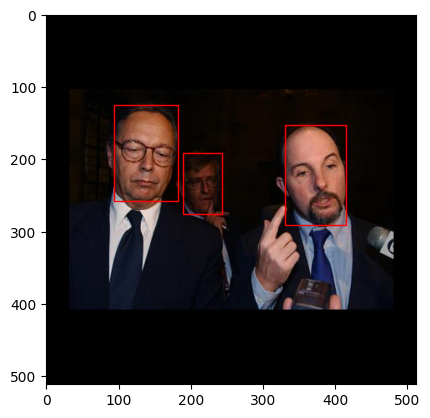

In [26]:
"""
KATEGORIER:
0 - Neutral
1 - Happy
2 - Sad
3 - Suprise
4 - Fear
5 - Disgust
6 - Anger
7 - Contempt
"""

%run faceDetection.ipynb
facefinder = torch.load('facefinder.pth')

tensor([[0.0035, 0.9120, 0.0359, 0.0025, 0.0064, 0.0364, 0.0014, 0.0021],
        [0.0361, 0.4304, 0.0735, 0.0547, 0.0367, 0.2140, 0.0286, 0.1261]],
       device='cuda:0', grad_fn=<SoftmaxBackward0>)


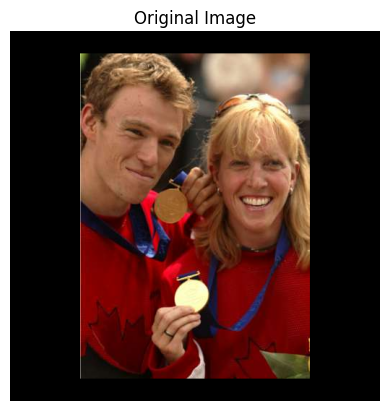

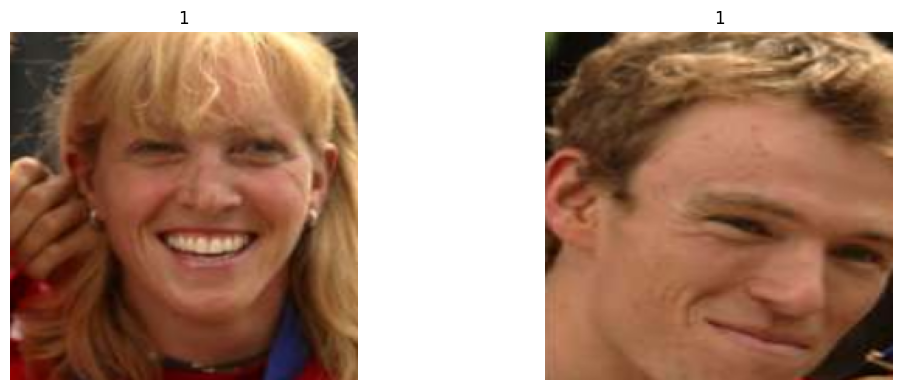

In [86]:

#index bildnummer, 0 är bild
pics, plotpics = get_selfies(facefinder, dataset[7][0])

pics = pics.to('cuda')

exp = Emotion_model(pics)
print(exp)
exp = torch.argmax(exp, dim=1)
scalar_values = [item.item() for item in exp]

show_multiple_images(plotpics, scalar_values)


    

In [ ]:
"""
KATEGORIER:
0 - Neutral
1 - Happy
2 - Sad
3 - Suprise
4 - Fear
5 - Disgust
6 - Anger
7 - Contempt
"""